In [28]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data Loading**

In [46]:
# Loadin dataset

sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv(       # The trader dataset contained a small number of malformed rows.
"historical_data.csv",      # These rows were skipped during loading to ensure successful analysis, and few rows will not affect the whole insights
    on_bad_lines="skip",
    low_memory=False      #read whole file
)

print(sentiment.shape)
print(trader.shape)



(2644, 4)
(211224, 16)


**Data Cleaning**

In [30]:
# Missing Values

print("Missing values in Fear & Greed dataset")
print(sentiment.isnull().sum())

print("\nMissing values in Trader dataset")
print(trader.isnull().sum())

# Remove rows with missing values
trader = trader.dropna()

print(trader.isnull().sum())


Missing values in Fear & Greed dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in Trader dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [31]:
# Duplicate values

print("Duplicate rows in sentiment dataset:", sentiment.duplicated().sum())
print("Duplicate rows in trader dataset:", trader.duplicated().sum())

# Remove duplicate rows
trader = trader.drop_duplicates()



Duplicate rows in sentiment dataset: 0
Duplicate rows in trader dataset: 0


In [32]:
# Converting timestamps (the date columns)

# Convert sentiment date
sentiment["date"] = pd.to_datetime(sentiment["date"])

# Convert trader timestamp
trader["Timestamp IST"] = pd.to_datetime(
    trader["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

# Common date column for both the datasets

trader["date"] = trader["Timestamp IST"].dt.date
sentiment["date"] = sentiment["date"].dt.date


# Merging both datasets on dates

merged_df = pd.merge(
    trader,
    sentiment,
    on="date",
    how="left"
)

merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


**Analysis of data**

In [33]:
# Average pnl

avg_pnl = merged_df.groupby("classification")["Closed PnL"].mean().reset_index()

print(avg_pnl)

  classification  Closed PnL
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   42.743559
4        Neutral   34.307718


In [34]:
# Total PnL

total_pnl = merged_df.groupby("classification")["Closed PnL"].sum().reset_index()

print(total_pnl)

  classification    Closed PnL
0   Extreme Fear  7.391102e+05
1  Extreme Greed  2.715171e+06
2           Fear  3.357155e+06
3          Greed  2.150129e+06
4        Neutral  1.292921e+06


In [35]:
# Creating a win column

merged_df["Win"] = merged_df["Closed PnL"] > 0

# Calculating the win rate

win_rate = (
    merged_df.groupby("classification")["Win"]
    .mean() * 100
).reset_index()

print(win_rate)

  classification        Win
0   Extreme Fear  37.060748
1  Extreme Greed  46.494299
2           Fear  42.076750
3          Greed  38.482794
4        Neutral  39.699093


In [36]:
# Trade Frequency

trade_frequency = (
    merged_df.groupby("classification")
    .size()
    .reset_index(name="Number of Trades")
)

print(trade_frequency)

  classification  Number of Trades
0   Extreme Fear             21400
1  Extreme Greed             39992
2           Fear             61837
3          Greed             50303
4        Neutral             37686


In [37]:
# Average trade size

avg_trade_size = (
    merged_df.groupby("classification")["Size USD"]
    .mean()
    .reset_index()
)

print(avg_trade_size)

  classification     Size USD
0   Extreme Fear  5349.731843
1  Extreme Greed  3112.251565
2           Fear  7816.109931
3          Greed  5736.884375
4        Neutral  4782.732661


In [38]:
# Long Vs Short bias

long_short = (
    merged_df.groupby(["classification", "Side"])
    .size()
    .unstack(fill_value=0)
)

print(long_short)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


In [39]:
# Frequent Vs Infrequent traders

trades_per_account = (
    merged_df.groupby("Account")
    .size()
    .reset_index(name="Trade Count")
)

median_trades = trades_per_account["Trade Count"].median()

trades_per_account["Segment"] = trades_per_account["Trade Count"].apply(
    lambda x: "Frequent Trader" if x > median_trades else "Infrequent Trader"
)

print(trades_per_account.head())

                                      Account  Trade Count            Segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012         3818    Frequent Trader
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         7280    Frequent Trader
2  0x271b280974205ca63b716753467d5a371de622ab         3809    Frequent Trader
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4        13311    Frequent Trader
4  0x2c229d22b100a7beb69122eed721cee9b24011dd         3239  Infrequent Trader


In [40]:
# Winning Vs losing traders

trader_performance = (
    merged_df.groupby("Account")["Closed PnL"]
    .mean()
    .reset_index()
)

trader_performance["Segment"] = trader_performance["Closed PnL"].apply(
    lambda x: "Winning Trader" if x > 0 else "Losing Trader"
)

print(trader_performance.head())

                                      Account  Closed PnL         Segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768  Winning Trader
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654  Winning Trader
2  0x271b280974205ca63b716753467d5a371de622ab  -18.492043   Losing Trader
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530  Winning Trader
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011  Winning Trader


**Visualizations**

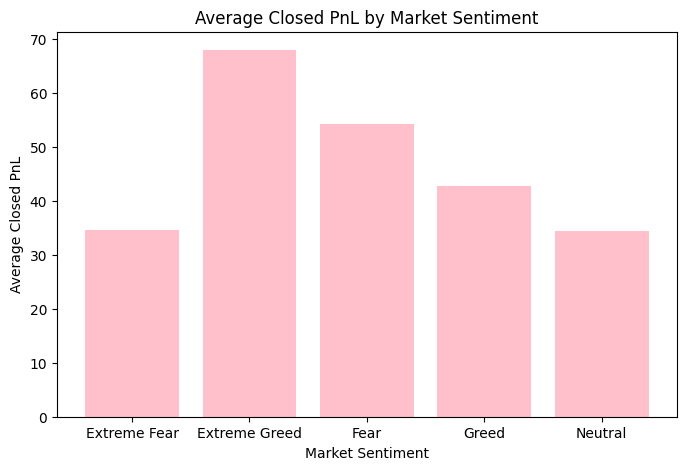

In [41]:
# Average PnL by Market sentiment
# It tells us if the performance differ in between fear and greed

plt.figure(figsize=(8,5))

plt.bar(avg_pnl["classification"], avg_pnl["Closed PnL"], color="pink")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

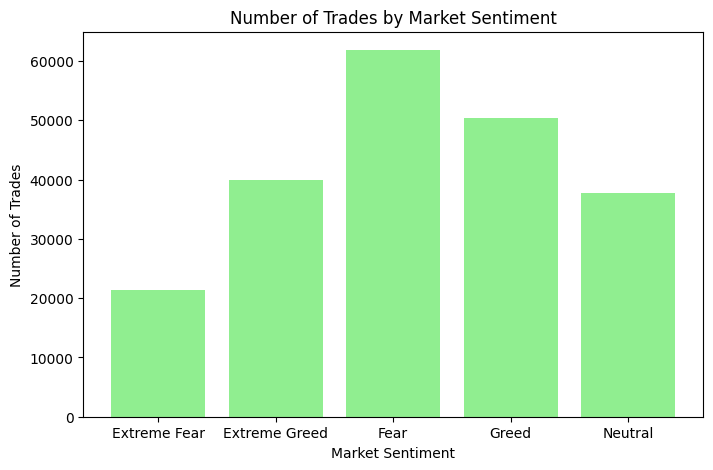

In [42]:
# Numbers of trades by Market sentiment
# it tell if the traders change trade frequency

plt.figure(figsize=(8,5))

plt.bar(trade_frequency["classification"],
        trade_frequency["Number of Trades"],
        color="lightgreen")

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

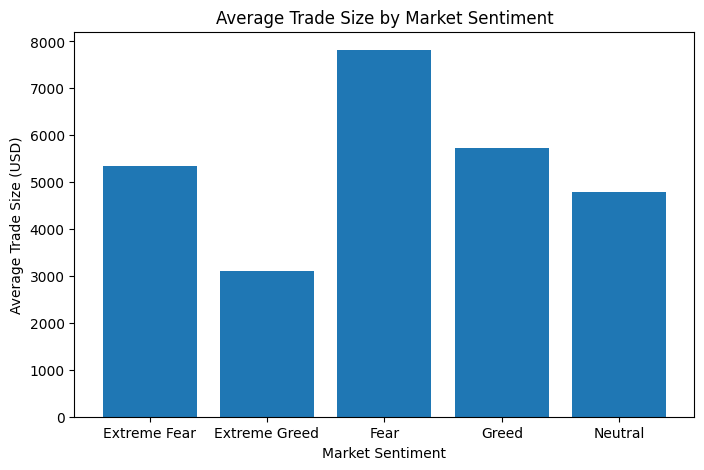

In [43]:
# Average trade size

plt.figure(figsize=(8,5))

plt.bar(avg_trade_size["classification"],
        avg_trade_size["Size USD"])

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.show()

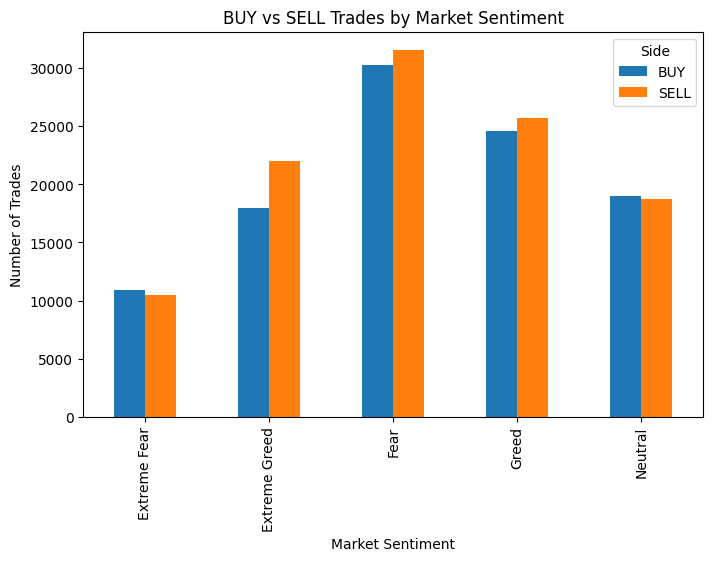

In [44]:
# BUY Vs SELL

long_short.plot(kind="bar", figsize=(8,5))

plt.title("BUY vs SELL Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

**Insights**
## Key Insights

1- Extreme Greed has the highest average PnL (67.89) and the highest win rate (46.49%). This shows that traders performed better during Extreme Greed compared to other market conditions.

2- Fear has the highest total PnL and the highest number of trades. This means traders were more active during Fear days.

3- The average trade size is highest during Fear. Traders made bigger trades during Fear than during other market sentiments

4- The number of BUY and SELL trades is almost equal in every market sentiment. There is no major difference in trade direction.

**Strategies recommendations**

1- Since traders performed better during Extreme Greed, they can continue trading but should avoid taking unnecessary risks.

2- During Fear, traders should manage their risk carefully because they make more trades and larger trades.